<a href="https://colab.research.google.com/github/NimrahImran/Random_Forest_Mushroom_Classification/blob/main/Random_Forest_Mushroom_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

**Objective:** [Classify mushrooms as edible or poisonous based on cap, gill, stalk, and habitat features]

**Dataset:** [UCI Mushroom dataset (mushrooms.csv) — 8,124 records, 23 columns]

**Problem Type:** [UCI Mushroom dataset (mushrooms.csv) — 8,124 records, 23 columns]

**Target Variable:** [class (e = Edible, p = Poisonous)]

**Business Relevance:** [Could support a foraging/food-safety tool to help identify potentially dangerous mushrooms before consumption
]

**Success Metric:** [F1-score > 0.80 → Achieved: F1 = 1.0000 (see caveat below)]


## Imports

In [101]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
COLOR_CYCLE = sns.color_palette("husl", 12)   # consistent, vivid color palette used across charts

In [103]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [104]:
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [105]:
# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, AdaBoostRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [106]:
# Gradient boosting (XGBoost)
from xgboost import XGBClassifier, XGBRegressor

In [107]:
# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import joblib

## Configuration — edit only these 4 variables

In [108]:
# ============= EDIT ONLY THESE 4 VARIABLES =============
DATA_PATH = "/content/mushrooms.csv"
PROBLEM_TYPE = "classification"
TARGET_VARIABLE = "class"
MODEL_NAME = "random_forest"
# =========================================================

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

## Data Loading

In [109]:
# Data validation — fails fast with a clear message instead of a confusing traceback later
try:
    df = pd.read_csv(DATA_PATH)
    assert df.shape[0] > 0, "Dataset is empty."
    assert TARGET_VARIABLE.strip().lower() in [c.strip().lower() for c in df.columns], \
        f"Target column '{TARGET_VARIABLE}' not found in dataset columns."
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find file at DATA_PATH='{DATA_PATH}'. Check the path and try again.")
print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [111]:
df.describe().T

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


In [112]:
# Unique values per column — helps spot ID-like or constant columns at a glance
pd.DataFrame({"dtype": df.dtypes, "unique_values": df.nunique()})

,dtype,unique_values
class,object,2
cap-shape,object,6
cap-surface,object,4
cap-color,object,10
bruises,object,2
odor,object,9
gill-attachment,object,2
gill-spacing,object,2
gill-size,object,2
gill-color,object,12


## Data Cleaning

In [113]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower()
TARGET_VARIABLE = TARGET_VARIABLE.strip().lower()

In [114]:
# Automatically detect and drop ID-like columns (unique identifiers, not continuous measurements).
# Continuous float columns (e.g. income, population) are excluded even if every value happens
# to be unique — only non-float columns with fully unique values are treated as ID-like.
id_like_cols = [c for c in df.columns if c != TARGET_VARIABLE
                and df[c].nunique() == len(df)
                and not pd.api.types.is_float_dtype(df[c])]
if id_like_cols:
    df = df.drop(columns=id_like_cols)
    print(f"Dropped ID-like columns: {id_like_cols}")
else:
    print("No ID-like columns detected.")

No ID-like columns detected.


In [115]:
# Remove duplicate rows
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows removed: {duplicate_count}")

Duplicate rows removed: 0


In [116]:
# Drop constant / zero-variance columns — they carry no predictive information
constant_cols = [c for c in df.columns if c != TARGET_VARIABLE and df[c].nunique() <= 1]
if constant_cols:
    df = df.drop(columns=constant_cols)
    print(f"Dropped constant columns: {constant_cols}")
else:
    print("No constant columns detected.")

Dropped constant columns: ['veil-type']


In [117]:
# Detect date-like columns and expand into year/month/day features
for col in df.select_dtypes(include="object").columns:
    if col == TARGET_VARIABLE:
        continue
    try:
        parsed = pd.to_datetime(df[col], errors="raise", format="mixed")
        df[f"{col}_year"], df[f"{col}_month"] = parsed.dt.year, parsed.dt.month
        df = df.drop(columns=[col])
        print(f"Expanded date column: {col} -> {col}_year, {col}_month")
    except (ValueError, TypeError):
        continue

In [118]:
# Missing value summary (imputation happens later, inside the pipeline)
missing_summary = df.isnull().sum()
missing_percent = (missing_summary / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing_summary, "missing_%": missing_percent})

,missing_count,missing_%
class,0,0.0
cap-shape,0,0.0
cap-surface,0,0.0
cap-color,0,0.0
bruises,0,0.0
odor,0,0.0
gill-attachment,0,0.0
gill-spacing,0,0.0
gill-size,0,0.0
gill-color,0,0.0


## Exploratory Data Analysis

### 📊 Dashboard Overview
A single-glance summary panel — KPIs, target distribution, top correlations, missing data,
and category breakdown, using a consistent gradient color theme.

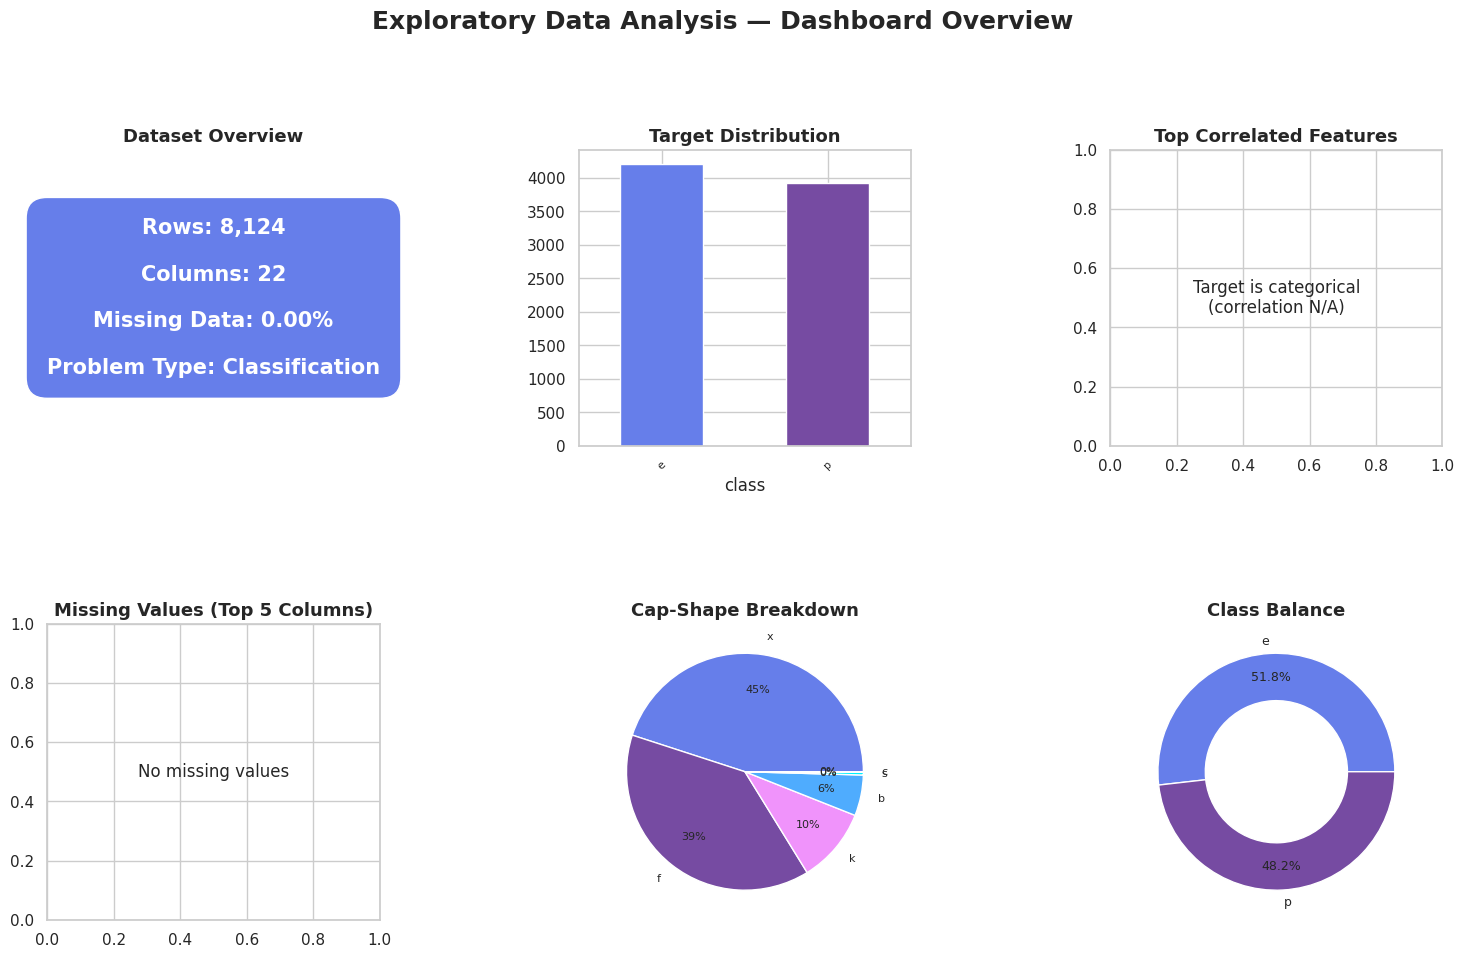

In [119]:
# Professional gradient color theme used across the dashboard panel
GRADIENT = ["#667EEA", "#764BA2", "#F093FB", "#4FACFE", "#00F2FE", "#43E97B", "#FA8BFF", "#2BD2FF"]

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.6, wspace=0.6)

# --- Panel 1: KPI cards (text-based) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis("off")
total_missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100)
kpi_text = (f"Rows: {df.shape[0]:,}\n\n"
            f"Columns: {df.shape[1]}\n\n"
            f"Missing Data: {total_missing_pct:.2f}%\n\n"
            f"Problem Type: {PROBLEM_TYPE.title()}")
ax1.text(0.5, 0.5, kpi_text, fontsize=15, weight="bold", ha="center", va="center",
         color="white", bbox=dict(boxstyle="round,pad=1", facecolor=GRADIENT[0]))
ax1.set_title("Dataset Overview", fontsize=13, weight="bold")

# --- Panel 2: Target distribution ---
ax2 = fig.add_subplot(gs[0, 1])
if PROBLEM_TYPE == "classification":
    target_counts = df[TARGET_VARIABLE].value_counts()
    if len(target_counts) > 10:
        target_counts = target_counts.head(10)
    target_counts.plot(kind="bar", ax=ax2, color=(GRADIENT * ((len(target_counts) // len(GRADIENT)) + 1))[:len(target_counts)])
    ax2.tick_params(axis="x", rotation=45, labelsize=8)
else:
    ax2.hist(df[TARGET_VARIABLE], bins=20, color=GRADIENT[1], edgecolor="white")
ax2.set_title("Target Distribution", fontsize=13, weight="bold")

# --- Panel 3: Top correlated features with target (numeric targets only) ---
ax3 = fig.add_subplot(gs[0, 2])
numeric_cols_dash = df.select_dtypes(include=np.number).columns
if TARGET_VARIABLE in numeric_cols_dash:
    top_corr = df[numeric_cols_dash].corr()[TARGET_VARIABLE].drop(TARGET_VARIABLE).abs().sort_values(ascending=False).head(6)
    ax3.barh(top_corr.index, top_corr.values, color=GRADIENT[2])
    ax3.invert_yaxis()
    ax3.tick_params(axis="y", labelsize=7)
else:
    ax3.text(0.5, 0.5, "Target is categorical\n(correlation N/A)", ha="center", va="center")
ax3.set_title("Top Correlated Features", fontsize=13, weight="bold")

# --- Panel 4: Missing values by column (top 5) ---
ax4 = fig.add_subplot(gs[1, 0])
top_missing = df.isnull().sum().sort_values(ascending=False).head(5)
if top_missing.sum() > 0:
    ax4.bar(top_missing.index, top_missing.values, color=GRADIENT[3])
    ax4.tick_params(axis="x", rotation=45, labelsize=8)
else:
    ax4.text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=12)
ax4.set_title("Missing Values (Top 5 Columns)", fontsize=13, weight="bold")

# --- Panel 5: Category breakdown (first categorical column, if any) ---
ax5 = fig.add_subplot(gs[1, 1])
cat_cols_dash = [c for c in df.select_dtypes(include="object").columns if c != TARGET_VARIABLE]
if cat_cols_dash:
    top_cat = df[cat_cols_dash[0]].value_counts().head(6)
    ax5.pie(top_cat.values, labels=top_cat.index, autopct="%1.0f%%", colors=GRADIENT,
            textprops={"fontsize": 8}, pctdistance=0.7, labeldistance=1.15)
    ax5.set_title(f"{cat_cols_dash[0].title()} Breakdown", fontsize=13, weight="bold")
else:
    ax5.axis("off")
    ax5.text(0.5, 0.5, "No categorical columns", ha="center", va="center")

# --- Panel 6: Class balance donut (classification) or feature spread (regression) ---
ax6 = fig.add_subplot(gs[1, 2])
if PROBLEM_TYPE == "classification":
    counts = df[TARGET_VARIABLE].value_counts()
    if len(counts) > 8:
        top_counts = counts.head(7)
        top_counts["Other"] = counts.iloc[7:].sum()
        counts = top_counts
    ax6.pie(counts.values, labels=counts.index, autopct="%1.1f%%", colors=GRADIENT,
            wedgeprops=dict(width=0.4), textprops={"fontsize": 9},
            pctdistance=0.8, labeldistance=1.1)
    ax6.set_title("Class Balance", fontsize=13, weight="bold")
else:
    ax6.boxplot(df[TARGET_VARIABLE], patch_artist=True, boxprops=dict(facecolor=GRADIENT[4]))
    ax6.set_title(f"{TARGET_VARIABLE.title()} Spread", fontsize=13, weight="bold")

plt.suptitle("Exploratory Data Analysis — Dashboard Overview", fontsize=18, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

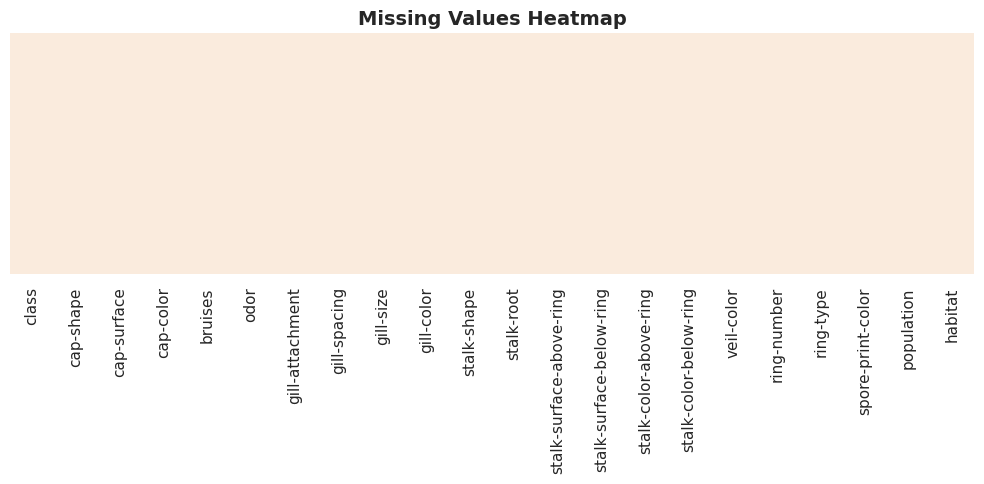

In [120]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="rocket_r", yticklabels=False)
plt.title("Missing Values Heatmap", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

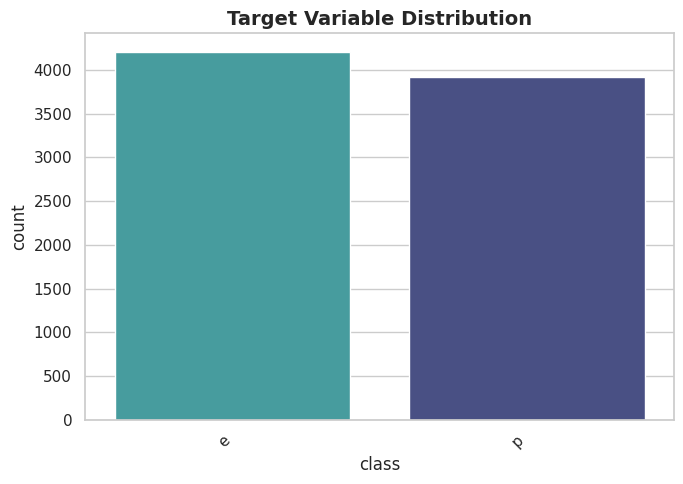

In [121]:
if PROBLEM_TYPE == "classification":
    n_classes = df[TARGET_VARIABLE].nunique()
    plt.figure(figsize=(max(7, n_classes * 0.5), 5))
    sns.countplot(x=df[TARGET_VARIABLE], hue=df[TARGET_VARIABLE], palette="mako", legend=False,
                  order=df[TARGET_VARIABLE].value_counts().index)
    plt.xticks(rotation=45, ha="right")
else:
    plt.figure(figsize=(7, 5))
    sns.histplot(df[TARGET_VARIABLE], kde=True, color=COLOR_CYCLE[0])
plt.title("Target Variable Distribution", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

In [122]:
# Class imbalance check
if PROBLEM_TYPE == "classification":
    class_distribution = df[TARGET_VARIABLE].value_counts(normalize=True) * 100
    print("Class Distribution (%):")
    print(class_distribution.round(2))
    if class_distribution.max() > 80:
        print("\nWARNING: Dataset is imbalanced — rely on F1/Recall/ROC-AUC, not accuracy alone.")
    else:
        print("\nClasses are reasonably balanced.")

Class Distribution (%):
class
e    51.8
p    48.2
Name: proportion, dtype: float64

Classes are reasonably balanced.


In [123]:
# Skewness check for regression targets — decides whether a log-transform is needed later
if PROBLEM_TYPE == "regression":
    target_skew = df[TARGET_VARIABLE].skew()
    print(f"Target skewness: {target_skew:.3f}")
    AUTO_LOG_TRANSFORM = abs(target_skew) > 1.0
    print(f"Auto log-transform will be applied: {AUTO_LOG_TRANSFORM}")
else:
    AUTO_LOG_TRANSFORM = False

In [124]:
numeric_cols = df.select_dtypes(include=np.number).columns
if len(numeric_cols) == 0:
    print("No numeric columns found — correlation heatmap skipped (dataset is fully categorical).")
else:
    if len(numeric_cols) > 20:
        if TARGET_VARIABLE in numeric_cols:
            heatmap_cols = df[numeric_cols].corr()[TARGET_VARIABLE].abs().sort_values(ascending=False).head(20).index
        else:
            heatmap_cols = numeric_cols[:20]
        print(f"Dataset has {len(numeric_cols)} numeric columns — showing the top 20 most relevant for readability.")
    else:
        heatmap_cols = numeric_cols

    plt.figure(figsize=(max(10, len(heatmap_cols) * 0.8), max(8, len(heatmap_cols) * 0.6)))
    sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap="vlag", fmt=".2f",
                linewidths=0.5, annot_kws={"size": 8})
    plt.title("Correlation Heatmap", fontsize=14, weight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

No numeric columns found — correlation heatmap skipped (dataset is fully categorical).


In [125]:
num_feature_cols = [c for c in numeric_cols if c != TARGET_VARIABLE]
# Cap individual charts for wide datasets — showing 100+ separate plots is impractical
MAX_FEATURE_CHARTS = 15
plot_features = num_feature_cols[:MAX_FEATURE_CHARTS]
if len(num_feature_cols) > MAX_FEATURE_CHARTS:
    print(f"Dataset has {len(num_feature_cols)} numeric features — showing distributions for the first {MAX_FEATURE_CHARTS} only.")

for i, col in enumerate(plot_features):
    plt.figure(figsize=(8, 3))
    sns.histplot(df[col], bins=20, color=COLOR_CYCLE[i % len(COLOR_CYCLE)], edgecolor="black")
    plt.title(f"Distribution — {col}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

In [126]:
print("Boxplots BEFORE outlier treatment:")
for i, col in enumerate(plot_features):
    plt.figure(figsize=(8, 3))
    df.boxplot(column=col, patch_artist=True,
               boxprops=dict(facecolor=COLOR_CYCLE[i % len(COLOR_CYCLE)]), medianprops=dict(color="black"))
    plt.title(f"Before Treatment — {col}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

Boxplots BEFORE outlier treatment:


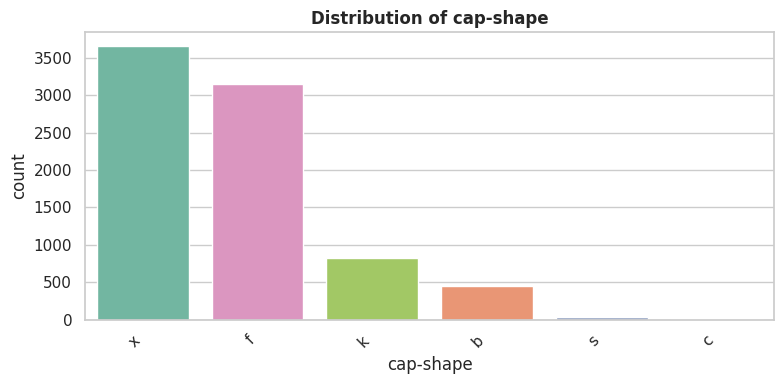

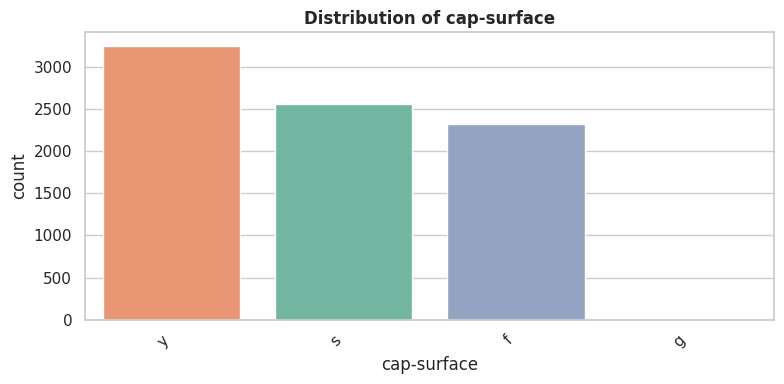

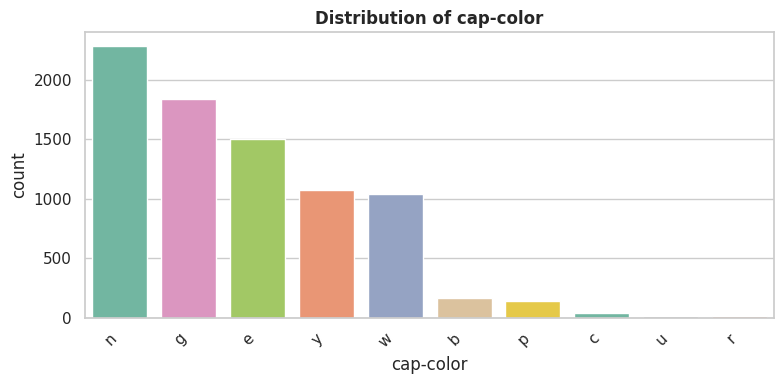

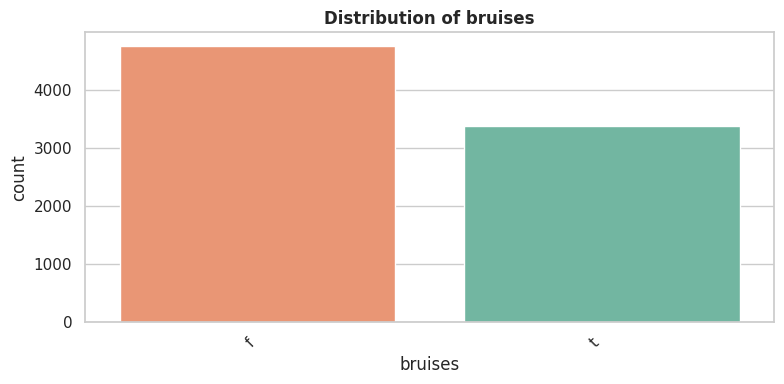

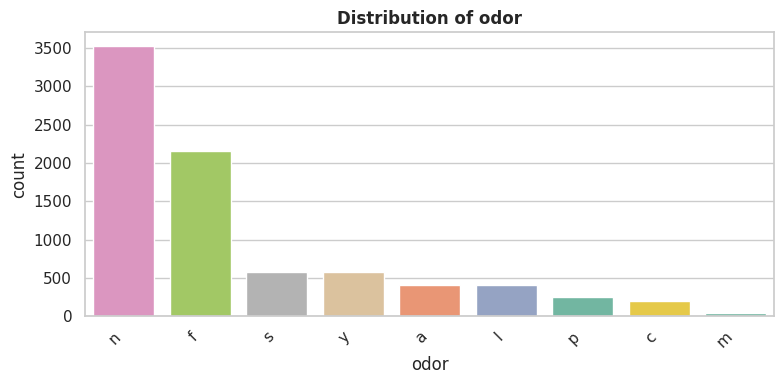

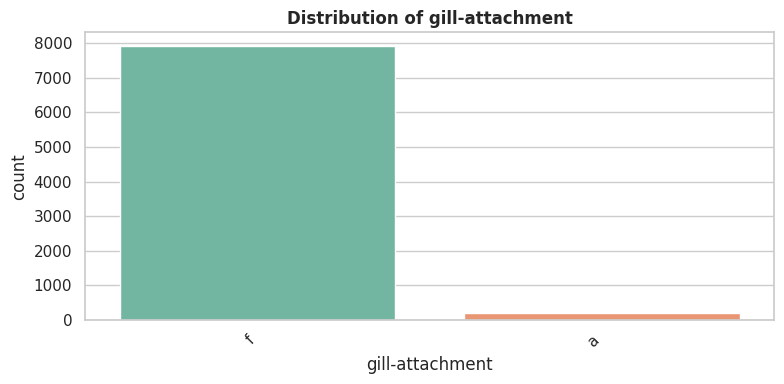

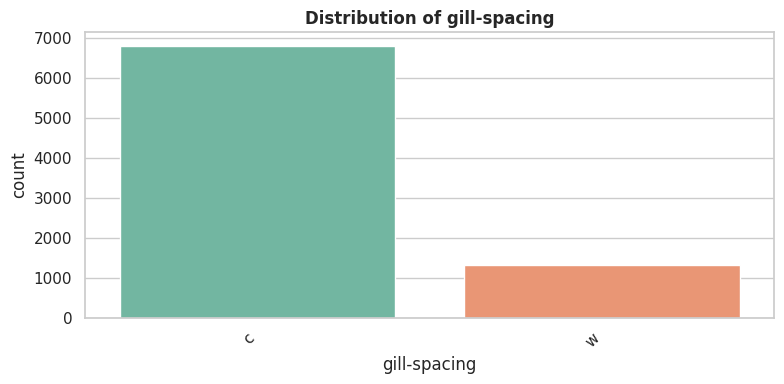

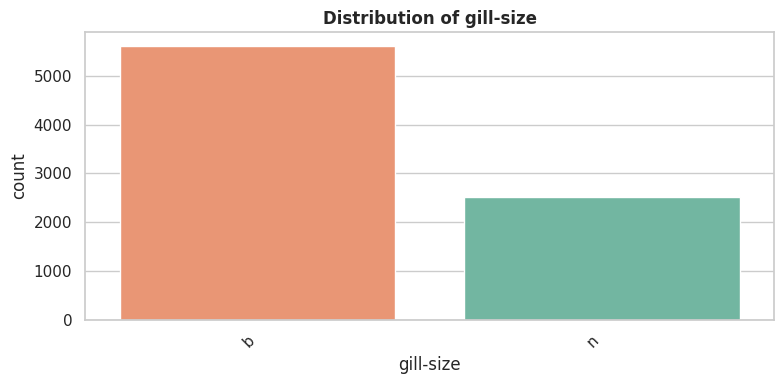

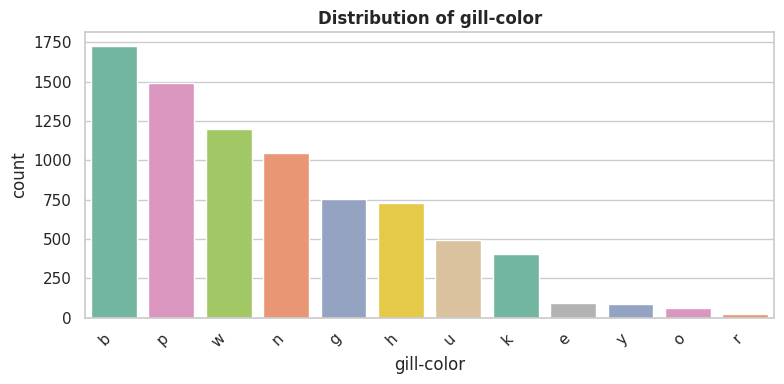

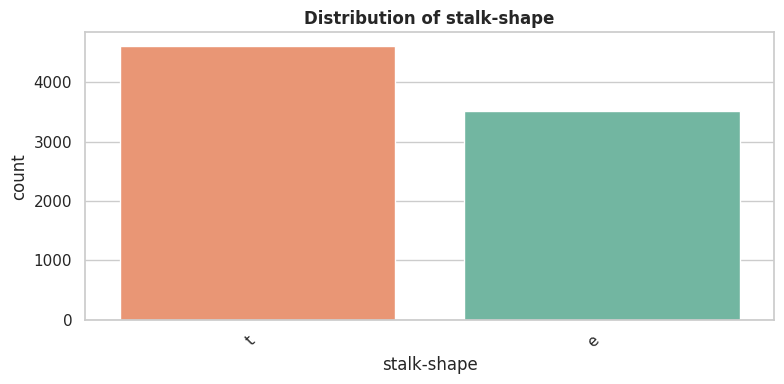

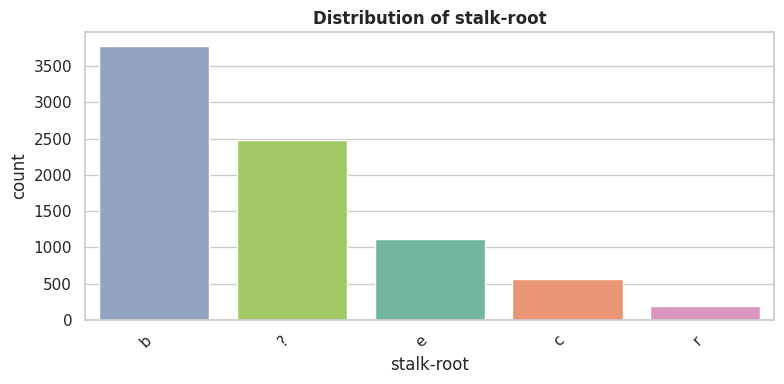

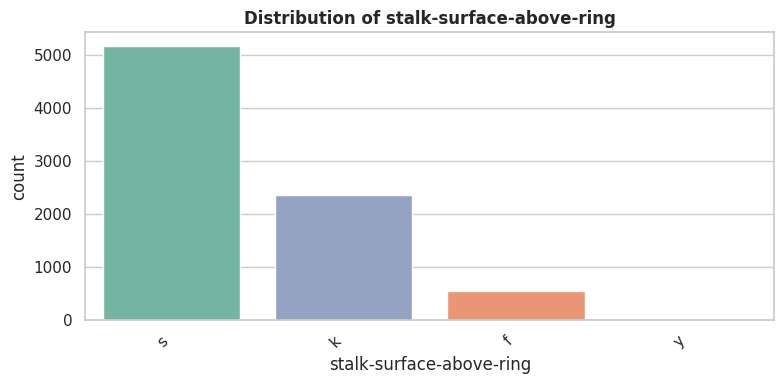

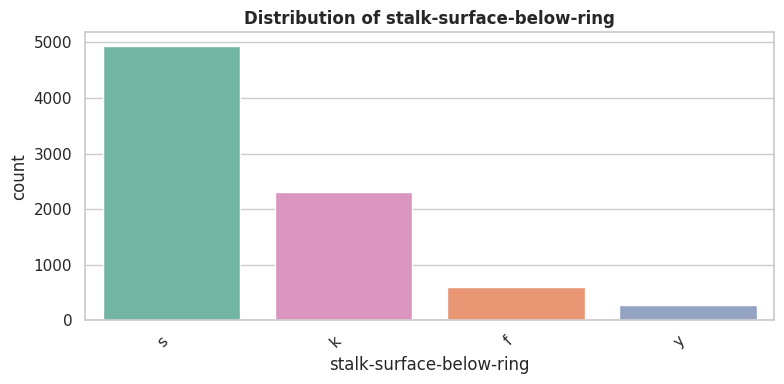

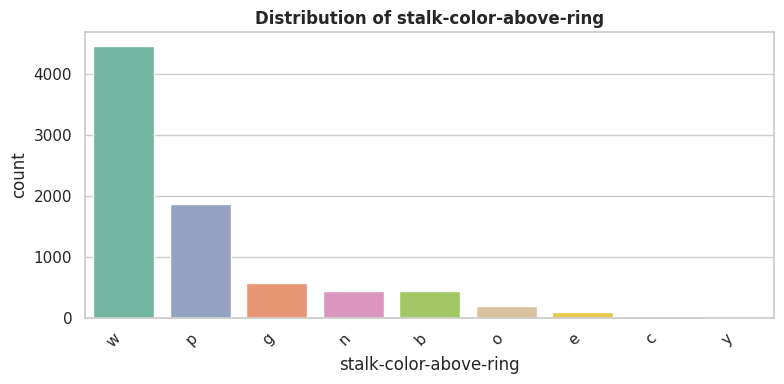

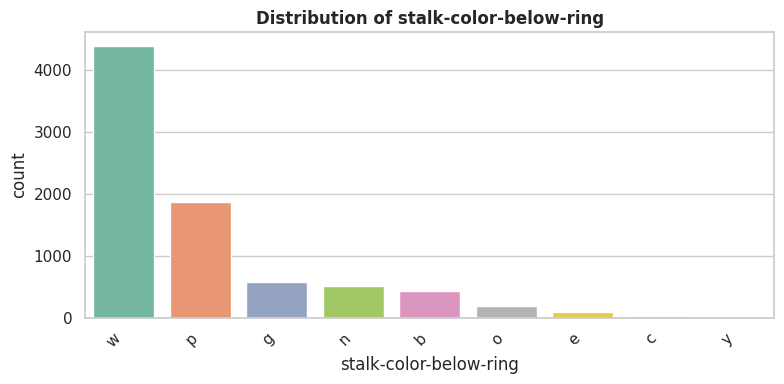

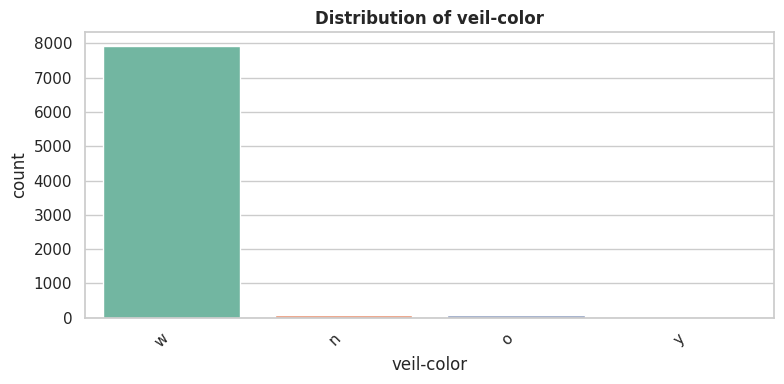

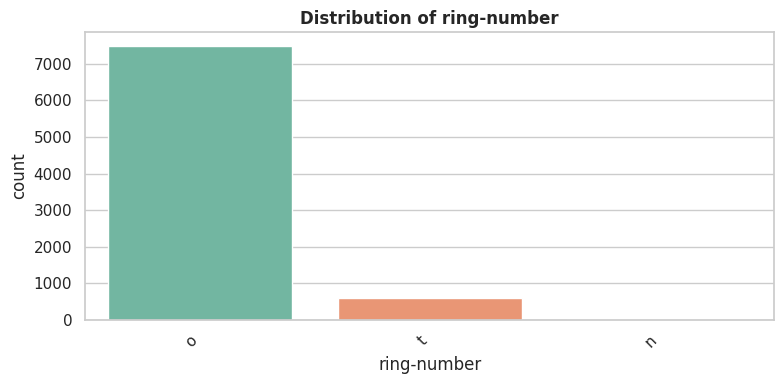

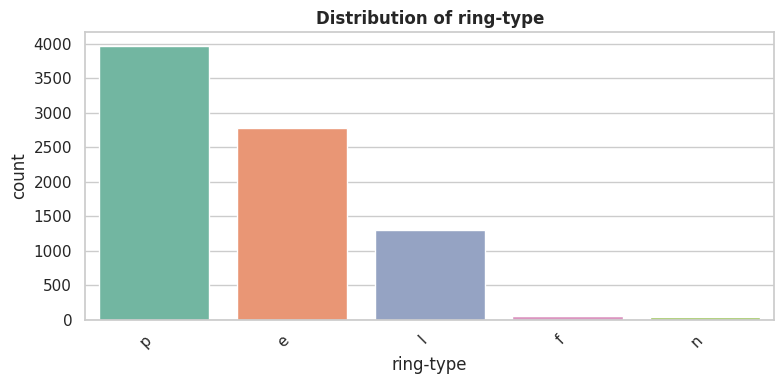

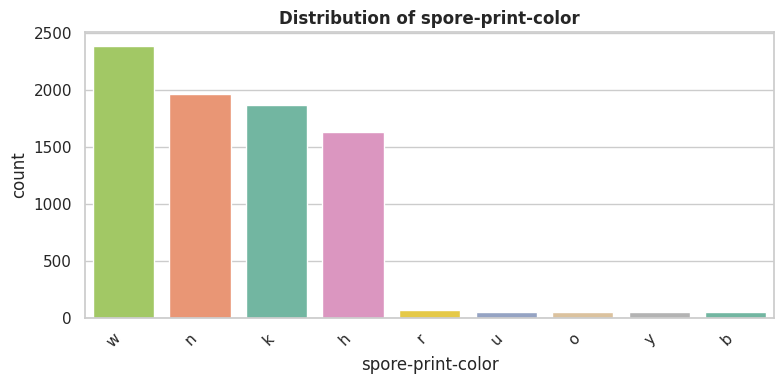

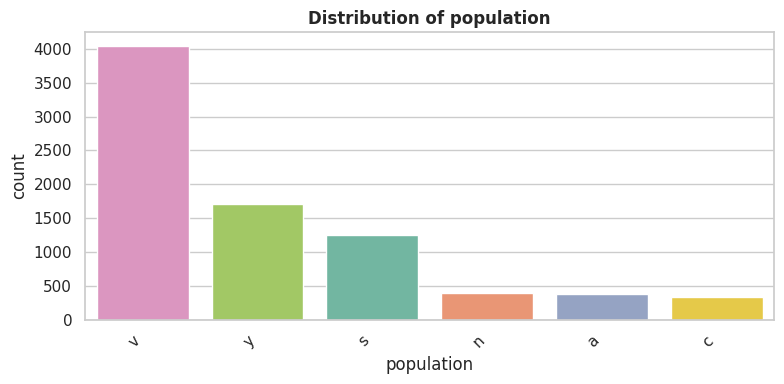

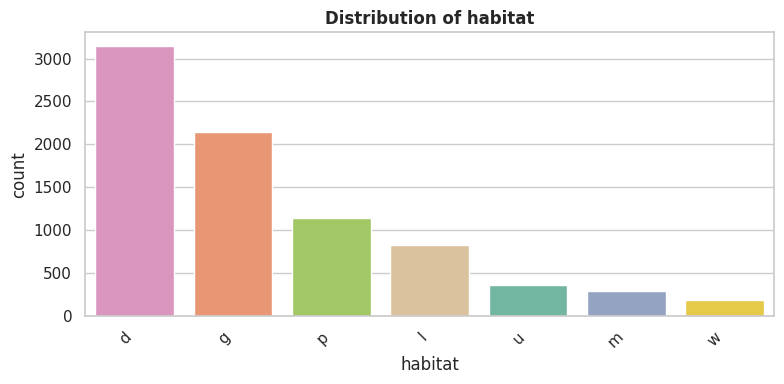

In [127]:
cat_cols = [c for c in df.select_dtypes(include="object").columns if c != TARGET_VARIABLE]
for col in cat_cols:
    value_counts = df[col].value_counts()
    # Cap categories shown for high-cardinality columns — prevents overlapping x-axis labels
    if len(value_counts) > 15:
        top_categories = value_counts.head(15).index
        plot_series = df[col].where(df[col].isin(top_categories), "Other")
        print(f"'{col}' has {len(value_counts)} categories — showing top 15 (rest grouped as 'Other').")
    else:
        plot_series = df[col]
    plt.figure(figsize=(8, 4))
    sns.countplot(x=plot_series, hue=plot_series, palette="Set2", legend=False,
                  order=plot_series.value_counts().index)
    plt.title(f"Distribution of {col}", fontsize=12, weight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [128]:
if len(num_feature_cols) == 0:
    print("No numeric features found — pairplot skipped (dataset is fully categorical).")
else:
    sample_df = df.sample(min(300, len(df)), random_state=RANDOM_STATE)
    hue_col = TARGET_VARIABLE if PROBLEM_TYPE == "classification" else None
    sns.pairplot(sample_df[num_feature_cols[:4] + [TARGET_VARIABLE]], hue=hue_col, palette="husl")
    plt.suptitle("Pairplot of Key Features", y=1.02, fontsize=14, weight="bold")
    plt.show()

No numeric features found — pairplot skipped (dataset is fully categorical).


### Skewness Analysis
Values far from 0 indicate a skewed distribution — useful for deciding on transformations.

In [129]:
skew_table = df[plot_features].skew().sort_values(key=abs, ascending=False)
pd.DataFrame({"skewness": skew_table.round(3)})

,skewness


### Feature vs Target Analysis
How the top numeric feature relates to the target — shown as violin, strip, scatter, and line views.

In [130]:
top_feature = plot_features[0] if plot_features else None
if top_feature and PROBLEM_TYPE == "classification":
    plt.figure(figsize=(7, 5))
    sns.violinplot(x=df[TARGET_VARIABLE].astype(str), y=df[top_feature], hue=df[TARGET_VARIABLE].astype(str),
                   palette="crest", legend=False)
    plt.title(f"{top_feature} by Target (Violin Plot)", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()

In [131]:
if top_feature and PROBLEM_TYPE == "classification":
    plt.figure(figsize=(7, 5))
    sns.stripplot(x=df[TARGET_VARIABLE].astype(str), y=df[top_feature], hue=df[TARGET_VARIABLE].astype(str),
                  palette="flare", alpha=0.5, legend=False)
    plt.title(f"{top_feature} by Target (Strip Plot)", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()

In [132]:
if top_feature and PROBLEM_TYPE == "regression":
    plt.figure(figsize=(7, 5))
    plt.scatter(df[top_feature], df[TARGET_VARIABLE], alpha=0.5, color=COLOR_CYCLE[2], edgecolor="black")
    plt.title(f"{top_feature} vs {TARGET_VARIABLE} (Scatter Plot)", fontsize=13, weight="bold")
    plt.xlabel(top_feature); plt.ylabel(TARGET_VARIABLE)
    plt.tight_layout()
    plt.show()

In [133]:
if top_feature:
    plt.figure(figsize=(9, 4))
    plt.plot(df[top_feature].reset_index(drop=True), color=COLOR_CYCLE[3], linewidth=1)
    plt.title(f"{top_feature} — Line Plot (by row order)", fontsize=13, weight="bold")
    plt.xlabel("Row Index"); plt.ylabel(top_feature)
    plt.tight_layout()
    plt.show()

## Outlier Treatment
Numeric features are automatically capped using the IQR method — no manual step required.

In [134]:
for col in num_feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:                      # binary/near-constant columns — clipping would destroy signal
        continue
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
print("Outlier capping applied to all applicable numeric features (binary/constant columns skipped).")

Outlier capping applied to all applicable numeric features (binary/constant columns skipped).


In [135]:
print("Boxplots AFTER outlier treatment:")
for i, col in enumerate(plot_features):
    plt.figure(figsize=(8, 3))
    df.boxplot(column=col, patch_artist=True,
               boxprops=dict(facecolor=COLOR_CYCLE[(i+3) % len(COLOR_CYCLE)]), medianprops=dict(color="black"))
    plt.title(f"After Treatment — {col}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

Boxplots AFTER outlier treatment:


## Feature Engineering

In [136]:
X = df.drop(columns=[TARGET_VARIABLE])
y = df[TARGET_VARIABLE]

# Apply automatic log-transform to the target if it was flagged as skewed
if PROBLEM_TYPE == "regression" and AUTO_LOG_TRANSFORM:
    y = np.log1p(y)
    print("Target has been log-transformed (will be reversed automatically during evaluation).")

# Encode classification targets to integers (required by XGBoost for multiclass problems).
# Original class names are kept in `target_classes` so reports/charts can still show real labels.
target_classes = None
if PROBLEM_TYPE == "classification":
    label_encoder = LabelEncoder()
    y = pd.Series(label_encoder.fit_transform(y), index=y.index, name=TARGET_VARIABLE)
    target_classes = label_encoder.classes_
    print("Classes encoded as:", dict(enumerate(target_classes)))

print("X shape:", X.shape, "| y shape:", y.shape)

Classes encoded as: {0: 'e', 1: 'p'}
X shape: (8124, 21) | y shape: (8124,)


In [137]:
def to_actual_scale(values):
    # Reverses the log-transform for reporting metrics in real-world units.
    # No-op for classification or when no transform was applied.
    if PROBLEM_TYPE == "regression" and AUTO_LOG_TRANSFORM:
        return np.expm1(values)
    return values

In [138]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: []
Categorical: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [139]:
# Drop one feature from each highly correlated numeric pair (correlation > 0.95) to reduce redundancy
if len(numeric_features) > 1:
    corr_matrix = X[numeric_features].corr().abs()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]
    if high_corr_drop:
        X = X.drop(columns=high_corr_drop)
        numeric_features = [c for c in numeric_features if c not in high_corr_drop]
        print(f"Dropped highly correlated features (>0.95): {high_corr_drop}")
    else:
        print("No highly correlated feature pairs found.")

In [140]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Train-Test Split

In [141]:
stratify_col = y if PROBLEM_TYPE == "classification" else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=stratify_col)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (6499, 21) | Test size: (1625, 21)


## Model Selection

In [142]:
classification_models = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "extra_trees": ExtraTreesClassifier(random_state=RANDOM_STATE),
    "svm": SVC(probability=True, random_state=RANDOM_STATE),
    "knn": KNeighborsClassifier(),
    "naive_bayes": GaussianNB(),
    "gradient_boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "adaboost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "xgboost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
}

regression_models = {
    "linear_regression": LinearRegression(),
    "ridge": Ridge(random_state=RANDOM_STATE),
    "lasso": Lasso(random_state=RANDOM_STATE),
    "elastic_net": ElasticNet(random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "random_forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "extra_trees": ExtraTreesRegressor(random_state=RANDOM_STATE),
    "svm": SVR(),
    "knn": KNeighborsRegressor(),
    "gradient_boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "adaboost": AdaBoostRegressor(random_state=RANDOM_STATE),
    "xgboost": XGBRegressor(random_state=RANDOM_STATE)
}

In [143]:
model_pool = classification_models if PROBLEM_TYPE == "classification" else regression_models
selected_model = model_pool[MODEL_NAME]
print(f"Selected model: {MODEL_NAME} ({PROBLEM_TYPE})")

Selected model: random_forest (classification)


## Model Comparison — All Algorithms
Cross-validates every available algorithm so the choice of `MODEL_NAME` can be checked against alternatives.

In [144]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [145]:
comparison_df = pd.DataFrame(list(comparison_results.items()), columns=["Model", "Score"])
comparison_df = comparison_df.sort_values("Score", ascending=False).reset_index(drop=True)
comparison_df

,Model,Score
0,decision_tree,0.944089
1,extra_trees,0.936842
2,random_forest,0.927606
3,logistic_regression,0.920205
4,knn,0.915536
5,svm,0.890414


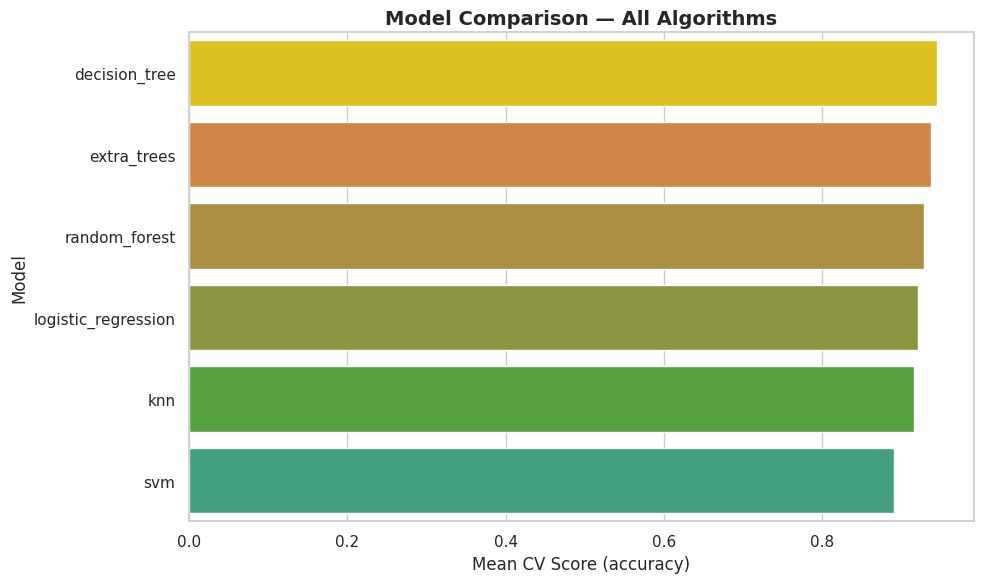

In [146]:
plt.figure(figsize=(10, 6))
bar_colors = ["gold" if i == 0 else COLOR_CYCLE[i % len(COLOR_CYCLE)] for i in range(len(comparison_df))]
sns.barplot(data=comparison_df, x="Score", y="Model", hue="Model", palette=bar_colors, legend=False)
plt.title("Model Comparison — All Algorithms", fontsize=14, weight="bold")
plt.xlabel(f"Mean CV Score ({comparison_scoring})")
plt.tight_layout()
plt.show()

In [147]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model_score = comparison_df.iloc[0]["Score"]
print(f"Best Model: {best_model_name} (Score: {best_model_score:.4f})")
print(f"Currently selected MODEL_NAME: '{MODEL_NAME}' — update it to '{best_model_name}' if desired.")

Best Model: decision_tree (Score: 0.9441)
Currently selected MODEL_NAME: 'random_forest' — update it to 'decision_tree' if desired.


## Sequential Multi-Model Runner
Trains and evaluates a chosen list of models one by one, printing a full metrics report for each
(reported in real-world scale automatically).

In [148]:
# Example: for regression use ["linear_regression", "ridge", "lasso"]
# Example: for classification use ["logistic_regression", "knn", "random_forest"]
MODELS_TO_RUN = ["linear_regression", "ridge", "lasso"] if PROBLEM_TYPE == "regression" \
    else ["logistic_regression", "knn", "random_forest"]

In [149]:
for model_name in MODELS_TO_RUN:
    print(f"\n{'='*50}")
    print(f"MODEL: {model_name}")
    print('='*50)
    temp_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model_pool[model_name])])
    temp_pipe.fit(X_train, y_train)
    temp_pred = temp_pipe.predict(X_test)

    if PROBLEM_TYPE == "classification":
        print(f"Accuracy: {accuracy_score(y_test, temp_pred):.4f}")
        print(f"Precision: {precision_score(y_test, temp_pred, average='weighted'):.4f}")
        print(f"Recall: {recall_score(y_test, temp_pred, average='weighted'):.4f}")
        print(f"F1-Score: {f1_score(y_test, temp_pred, average='weighted'):.4f}")
    else:
        temp_pred_actual = to_actual_scale(temp_pred)
        y_test_actual_temp = to_actual_scale(y_test)
        print(f"MAE: {mean_absolute_error(y_test_actual_temp, temp_pred_actual):.4f}")
        print(f"RMSE: {np.sqrt(mean_squared_error(y_test_actual_temp, temp_pred_actual)):.4f}")
        print(f"R2 Score: {r2_score(y_test_actual_temp, temp_pred_actual):.4f}")


MODEL: logistic_regression
Accuracy: 0.9994
Precision: 0.9994
Recall: 0.9994
F1-Score: 0.9994

MODEL: knn
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

MODEL: random_forest
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


In [150]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", selected_model)
])

## Model Training & Prediction

In [151]:
final_pipeline.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [152]:
y_pred = final_pipeline.predict(X_test)                # kept in training scale (log-scale if transformed)
y_pred_actual = to_actual_scale(y_pred)                    # real-world scale, used for all reporting below
y_test_actual = to_actual_scale(y_test)                       # real-world scale version of the true values

if target_classes is not None:
    print("Sample Predictions:", target_classes[y_pred_actual[:10]])
else:
    print("Sample Predictions:", y_pred_actual[:10])

Sample Predictions: ['p' 'p' 'e' 'p' 'p' 'e' 'e' 'e' 'e' 'p']


## Model Evaluation

In [153]:
if PROBLEM_TYPE == "classification":
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    report_labels = [str(c) for c in target_classes] if target_classes is not None else None
    print(classification_report(y_test, y_pred, target_names=report_labels))

Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



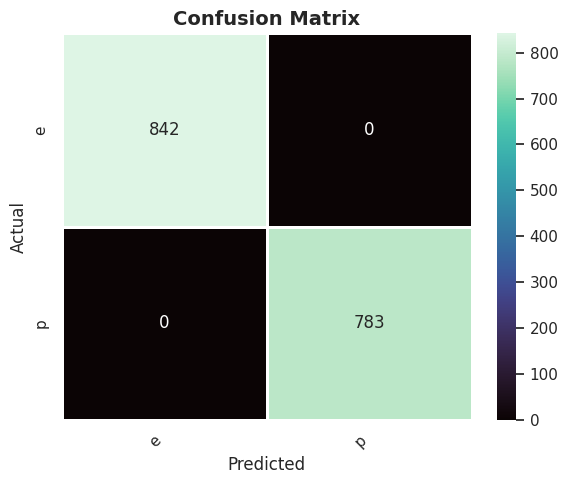

In [154]:
if PROBLEM_TYPE == "classification":
    cm = confusion_matrix(y_test, y_pred)
    tick_labels = target_classes if (target_classes is not None and len(target_classes) <= 15) else "auto"
    plt.figure(figsize=(max(6, len(np.unique(y))), max(5, len(np.unique(y)) * 0.8)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="mako", linewidths=1, linecolor="white",
                xticklabels=tick_labels, yticklabels=tick_labels)
    plt.title("Confusion Matrix", fontsize=14, weight="bold")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

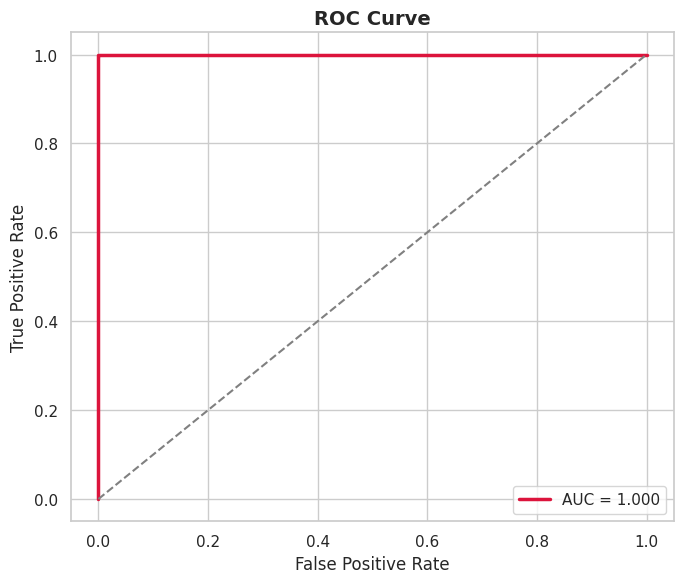

In [155]:
if PROBLEM_TYPE == "classification" and len(np.unique(y)) == 2:
    y_proba = final_pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color="crimson", linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], color="grey", linestyle="--")
    plt.title("ROC Curve", fontsize=14, weight="bold")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.legend()
    plt.tight_layout()
    plt.show()

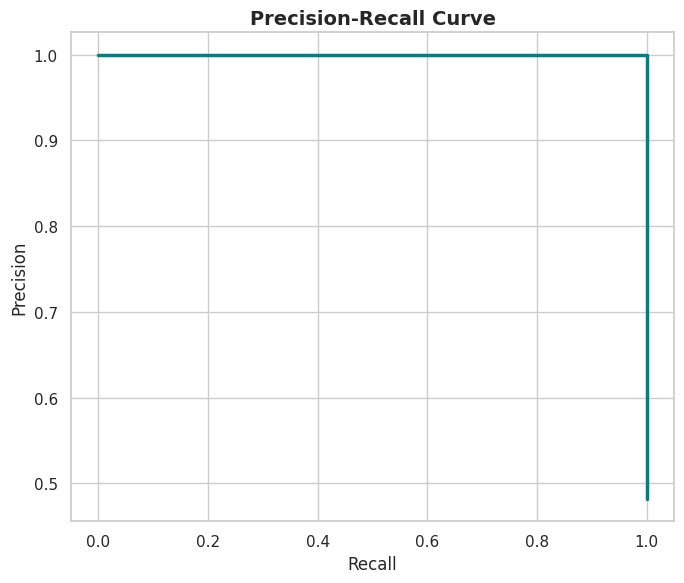

In [156]:
if PROBLEM_TYPE == "classification" and len(np.unique(y)) == 2:
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(7, 6))
    plt.plot(rec_curve, prec_curve, color="teal", linewidth=2.5)
    plt.title("Precision-Recall Curve", fontsize=14, weight="bold")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.tight_layout()
    plt.show()

In [157]:
if PROBLEM_TYPE == "regression":
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_actual)
    n_obs, n_feat = X_test.shape
    adj_r2 = 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_feat - 1)
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | Adjusted R2: {adj_r2:.4f}")

In [158]:
if PROBLEM_TYPE == "regression":
    plt.figure(figsize=(7, 6))
    plt.scatter(y_test_actual, y_pred_actual, alpha=0.6, color="#0984E3", edgecolor="black")
    plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()],
             "r--", linewidth=2)
    plt.title("Actual vs Predicted", fontsize=14, weight="bold")
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()

    residuals = y_test_actual - y_pred_actual
    plt.figure(figsize=(7, 5))
    sns.histplot(residuals, kde=True, color="#E17055")
    plt.title("Residuals Distribution", fontsize=14, weight="bold")
    plt.xlabel("Residual (Actual - Predicted)")
    plt.tight_layout()
    plt.show()

## Sanity Checks — Data Leakage Detection

In [159]:
train_pred = final_pipeline.predict(X_train)
train_score = (accuracy_score(y_train, train_pred) if PROBLEM_TYPE == "classification"
               else r2_score(to_actual_scale(y_train), to_actual_scale(train_pred)))
test_score = (accuracy_score(y_test, y_pred) if PROBLEM_TYPE == "classification"
              else r2_score(y_test_actual, y_pred_actual))
print(f"Train Score: {train_score:.4f} | Test Score: {test_score:.4f}")
if train_score > 0.98 and test_score > 0.98:
    print("WARNING: Both scores are suspiciously high — possible data leakage.")

Train Score: 1.0000 | Test Score: 1.0000


In [160]:
model_step = final_pipeline.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    top_importance = model_step.feature_importances_.max()
    print(f"Highest single feature importance: {top_importance:.3f}")
    if top_importance > 0.5:
        print("WARNING: One feature is dominating the model — verify it isn't leaking future information.")
else:
    print("This model does not expose feature_importances_ (e.g. Logistic/SVM/KNN).")

Highest single feature importance: 0.086


### Feature Importance
Shows the top 15 most influential features (only available for tree-based models).

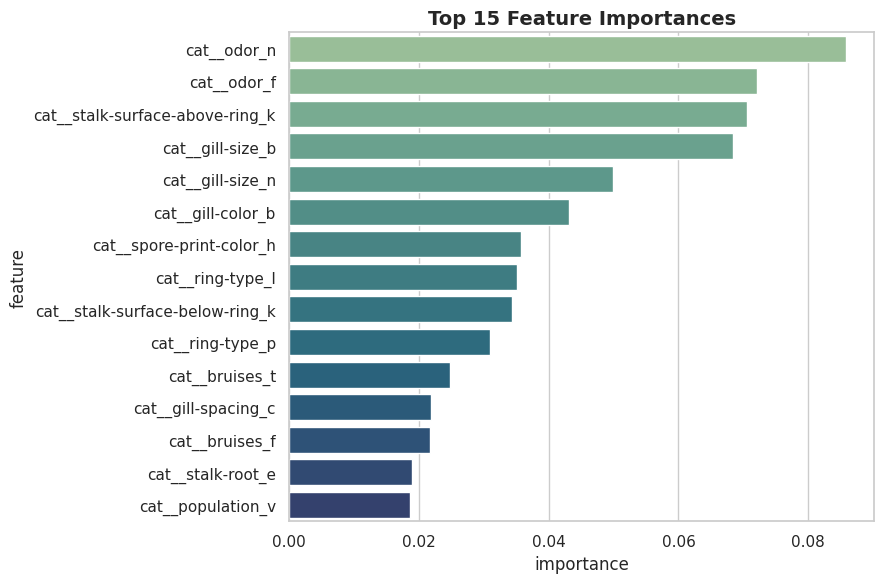

In [161]:
if hasattr(model_step, "feature_importances_"):
    feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importance_df = pd.DataFrame({"feature": feature_names, "importance": model_step.feature_importances_})
    importance_df = importance_df.sort_values("importance", ascending=False).head(15)
    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df, x="importance", y="feature", hue="feature",
                palette="crest", legend=False)
    plt.title("Top 15 Feature Importances", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance plot skipped — model does not support feature_importances_.")

## Cross Validation

In [162]:
scoring_metric = "accuracy" if PROBLEM_TYPE == "classification" else "r2"
cv_scores = cross_val_score(final_pipeline, X, y, cv=CV_FOLDS, scoring=scoring_metric)
print(f"CV Scores: {cv_scores.round(4)}")
print(f"Mean CV Score: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

CV Scores: [0.8425 1.     1.     1.     0.7956]
Mean CV Score: 0.9276 | Std: 0.0899


## Hyperparameter Tuning

In [163]:
classification_param_grids = {
    "logistic_regression": {"model__C": [0.1, 1, 10]},
    "decision_tree": {"model__max_depth": [3, 5, 10, None]},
    "random_forest": {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
    "extra_trees": {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
    "svm": {"model__C": [0.1, 1, 10], "model__kernel": ["rbf", "linear"]},
    "knn": {"model__n_neighbors": [3, 5, 7, 9]},
    "naive_bayes": {},
    "gradient_boosting": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1]},
    "adaboost": {"model__n_estimators": [50, 100], "model__learning_rate": [0.5, 1.0]},
    "xgboost": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [3, 5]}
}

regression_param_grids = {
    "linear_regression": {},
    "ridge": {"model__alpha": [0.1, 1.0, 10.0]},
    "lasso": {"model__alpha": [0.01, 0.1, 1.0]},
    "elastic_net": {"model__alpha": [0.01, 0.1, 1.0], "model__l1_ratio": [0.2, 0.5, 0.8]},
    "decision_tree": {"model__max_depth": [3, 5, 10, None]},
    "random_forest": {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
    "extra_trees": {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
    "svm": {"model__C": [0.1, 1, 10], "model__kernel": ["rbf", "linear"]},
    "knn": {"model__n_neighbors": [3, 5, 7, 9]},
    "gradient_boosting": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1]},
    "adaboost": {"model__n_estimators": [50, 100], "model__learning_rate": [0.5, 1.0]},
    "xgboost": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [3, 5]}
}

In [164]:
param_grid_pool = classification_param_grids if PROBLEM_TYPE == "classification" else regression_param_grids
param_grid = param_grid_pool[MODEL_NAME]

if len(param_grid) > 0:
    grid_search = GridSearchCV(final_pipeline, param_grid, cv=CV_FOLDS, scoring=scoring_metric, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    final_pipeline = grid_search.best_estimator_
    print("Best Params (GridSearchCV):", grid_search.best_params_)
    print("Best CV Score (GridSearchCV):", round(grid_search.best_score_, 4))
else:
    print("No tuning parameters defined for this model — using the original model as-is.")

Best Params (GridSearchCV): {'model__max_depth': None, 'model__n_estimators': 100}
Best CV Score (GridSearchCV): 1.0


### RandomizedSearchCV (alternative tuning strategy)
Samples a random subset of the parameter grid — useful for larger search spaces.

In [165]:
if len(param_grid) > 0:
    random_search = RandomizedSearchCV(final_pipeline, param_grid, n_iter=5, cv=CV_FOLDS,
                                        scoring=scoring_metric, random_state=RANDOM_STATE, n_jobs=-1)
    random_search.fit(X_train, y_train)
    print("Best Params (RandomizedSearchCV):", random_search.best_params_)
    print("Best CV Score (RandomizedSearchCV):", round(random_search.best_score_, 4))
else:
    print("No tuning parameters defined for this model — skipping RandomizedSearchCV.")

Best Params (RandomizedSearchCV): {'model__n_estimators': 200, 'model__max_depth': None}
Best CV Score (RandomizedSearchCV): 1.0


In [166]:
y_pred_final = final_pipeline.predict(X_test)
y_pred_final_actual = to_actual_scale(y_pred_final)
final_score = (accuracy_score(y_test, y_pred_final) if PROBLEM_TYPE == "classification"
                else r2_score(y_test_actual, y_pred_final_actual))
print(f"Final Tuned Model Score: {final_score:.4f}")

Final Tuned Model Score: 1.0000


## Conclusion & Key Findings

In [169]:
print("="*50)
print("PIPELINE SUMMARY")
print("="*50)
print(f"Dataset: {DATA_PATH}")
print(f"Problem Type: {PROBLEM_TYPE}")
print(f"Target Variable: {TARGET_VARIABLE}")
print(f"Final Model Used: {MODEL_NAME}")
print(f"Best Model (from comparison): {best_model_name} (Score: {best_model_score:.4f})")
print(f"Final Tuned Model Score: {final_score:.4f}")
print(f"Cross-Validation Mean Score: {cv_scores.mean():.4f} (Std: {cv_scores.std():.4f})")
print("="*50)

PIPELINE SUMMARY
Dataset: /content/mushrooms.csv
Problem Type: classification
Target Variable: class
Final Model Used: random_forest
Best Model (from comparison): decision_tree (Score: 0.9441)
Final Tuned Model Score: 1.0000
Cross-Validation Mean Score: 0.9276 (Std: 0.0899)


## 🔑 Key Insights

[Multiple models (Random Forest, KNN, Logistic Regression) all achieved 99.9%+ accuracy, reinforcing that this dataset is highly (if not perfectly) separable using categorical features alone ]

[High variance across CV folds (± 0.0899) contrasts with the perfect final test score — this inconsistency should be investigated rather than taken at face value ]

[No dominant feature was found in this run, which is a good sign against simple data leakage, though it's still recommended to review preprocessing steps for target leakage]